# Grokking Modular Addition (Now with transformers!)

This notebook aims to apply the LLC estimation method in the [basic toy model of modular addition](https://github.com/timaeus-research/devinterp/blob/main/examples/grokking.ipynb) within the context of the findings of [The Clock and the Pizza](https://arxiv.org/pdf/2306.17844).

**Note**: Results regenerate on full notebook run. Persisting to disk not implemented.

### Background
- [Grokking paper](https://www.alignmentforum.org/posts/4v3hMuKfsGatLXPgt/investigating-the-learning-coefficient-of-modular-addition)
- [LLC / devinterp](https://arxiv.org/abs/2308.12108)
- [Pizza and Clock paper](https://arxiv.org/abs/2306.17844)


In this notebook we investigate how the local learning coefficient (LLC) evolves after grokking modular arithmetic for different architectures (Transformer, MLP, Const Attention).

The authors of https://arxiv.org/pdf/2306.17844 have found that models can learn different algorithms to perform this task.

#### Model Structures

3 models are trained to perform modular arithmetic: The models are specifically trained to learn the operation `(a+b) % p`, where `a,b` are inputs, and `p` is fixed (in this notebook, `p=59`)

1. A single layer transformer with learned positional encodings and constant attention. Corresponds to `ModelA` in Pizza/Clock.
2. A single layer transformer with learned positional encodings. Corresponds to `ModelB` in Pizza/Clock.
3. A single layer MLP.

#### The Local Learning Coefficient (LLC)

The LLC arises from the field of singular learning theory and serves as a general metric of "model complexity" in a neural network.

The [formal definition of the LLC](https://arxiv.org/abs/2308.12108) is quite dense and gets into the realm of algebraic geometry. For our purposes, we can regard the LLC as "lower LLC = less dimensions used by the model".

For most models, the LLC must be estimated, ironically enough, through machine learning techniques such as SGLD.

#### Algorithm Metrics

There are two key differences between "Pizza" and "Clock" algorithms

In order to trace model behavior, three metrics were used. **Gradient Symmetricity** and **Distance Irrelevance** are as defined in the Pizza/Clock paper.

A third metric, **Pairwise Gradient Symmetry** is computed by passing input `(a+b)%p` and `(b+a)%p` and comparing gradient symmetry. This was used as an additional signal for measuring if the underlying algorithm was commutative. Although this felt intuitive to create at the time, there was significant difference between pairwise and original gradient symmetry which either suggest a flaw in this metric, or would require further investigation.

### Imports and Setup

In [ ]:
%pip install devinterp nbformat

In [ ]:
import random
import math
from copy import copy, deepcopy
from dataclasses import dataclass

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm

from devinterp.optim.sgld import SGLD
from devinterp.slt.sampler import estimate_learning_coeff_with_summary
from devinterp.utils import evaluate_ce
from devinterp.utils import plot_trace

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

### Model Definitions

In [ ]:
@dataclass
class ExperimentParams:
    p: int = 59
    n_batches: int = 25000 # This is a *lot* (and the model groks pretty early), but we want to see how LLC evolves
    n_save_model_checkpoints: int = 100
    print_times: int = 100
    lr: float = .001
    train_frac: float = 0.6
    batch_size: int = 100
    random_seed: int = 42
    device: str = DEVICE
    weight_decay: float = .5

@dataclass
class TransformerExperimentParams(ExperimentParams):
    n_attn_heads: int = 4
    d_model: int = 128
    d_mlp: int = d_model * 4
    use_constant_attn: bool = False
    pos_embed_type: str = "learned" # oneof "const", "learned", "none"

@dataclass
class MlpExperimentParams(ExperimentParams):
    hidden_size: int = 256
    embed_dim: int = 128

@dataclass
class LlcEstimationParams:
    lr: float = 5e-6
    gamma: float = 100
    nbeta: int = 100
    num_draws: int = 500
    num_chains: int = 1
    batch_size: int = 128
    num_burnin_steps: int = 2000

class Transformer(nn.Module):
    """Expected to be able to learn 'Clock' modular addition algorithm when
    attention is not constant, and positional embeddings are not ablated.
    """
    class ConstantAttention(nn.Module):
        def __init__(self, d_model):
            super().__init__()
            max_ctx = 2 # Hardcoded for now
            self.W_v = nn.Linear(d_model, d_model, bias=False)
            self.W_o = nn.Linear(d_model, d_model, bias=False)
            self.register_buffer('attn', torch.ones(max_ctx, max_ctx) / max_ctx)

        def forward(self,q, k, v, need_weights=False):
            V = self.W_v(v)
            out = self.attn @ V
            return self.W_o(out), None



    class PosEncode(nn.Module):
        def __init__(self, d_model, pe_type):
            super().__init__()
            max_ctx = 2 # Hardcoded for now
            if pe_type == "const":
                self.register_buffer('W_pos', torch.tensor([0, 1.0])[:, None])
            else:
                self.W_pos = nn.Parameter(torch.randn(max_ctx, d_model)/math.sqrt(d_model))

        def forward(self, x):
            return x+self.W_pos[:x.shape[-2]]


    def __init__(self, params):
        super().__init__()
        self.embedding = nn.Embedding(params.p, params.d_model)
        if params.pos_embed_type == "none":
            self.pos_embed = None
        else:
            self.pos_embed = Transformer.PosEncode(params.d_model, params.pos_embed_type)

        if not params.use_constant_attn:
            self.attn = nn.MultiheadAttention(params.d_model, params.n_attn_heads, batch_first=True)
        else:
            self.attn = Transformer.ConstantAttention(params.d_model)
        # No layer norm;
        self.linear1 = nn.Linear(params.d_model, params.d_mlp)
        self.act = nn.ReLU()
        self.linear2 = nn.Linear(params.d_mlp, params.d_model)

        self.unembed = nn.Linear(params.d_model, params.p)
        self.vocab_size = params.p

    def forward(self, x, return_intermediates=False):
        e1 = self.embedding(x[..., 0])
        e2 = self.embedding(x[..., 1])
        x = torch.stack((e1, e2), dim=-2)
        if self.pos_embed:
            x = self.pos_embed(x)
        h, _ = self.attn(x, x, x, need_weights=False)
        x = x + h
        x = x + self.linear2(self.act(self.linear1(x)))

        x = self.unembed(x)
        if len(x.shape) > 2:
            x = x[...,-1,:]
        else:
            x = x[-1,:]
        if not return_intermediates:
            return x
        return x, e1, e2

class MLP(nn.Module):
    """Expected to learn 'Pizza' modular addition algorithm
    """
    def __init__(self, params):
        super().__init__()
        self.embedding = nn.Embedding(params.p, params.embed_dim)
        self.linear1r = nn.Linear(params.embed_dim, params.hidden_size, bias=True)
        self.linear1l = nn.Linear(params.embed_dim, params.hidden_size, bias=True)
        self.linear2 = nn.Linear(params.hidden_size, params.p, bias=False)
        self.act = nn.ReLU()
        self.vocab_size = params.p

    def forward(self, x, return_intermediates=False):
        e1 = self.embedding(x[..., 0])
        e2 = self.embedding(x[..., 1])
        x1 = self.linear1l(e1)
        x2 = self.linear1r(e2)
        x = x1 + x2
        x = self.act(x)
        x = self.linear2(x)
        if not return_intermediates:
            return x
        return x, e1, e2

def grad_pair(model, dataset, device, n_samples=100):
    """Since `(a+b)%p == (b+a)%p`, we can check sensitivity to argument ordering
    by comparing the behavior with input x1=[a,b] and x2=[b,a]

    If Ea(x1) and Eb(x2) have similar gradients, this may imply input symmetry
    """
    model.eval()
    p = model.vocab_size
    # Random (a, b, c) including wrong classes
    xs = [(a, b) for a in range(p) for b in range(p)]
    random.shuffle(xs)
    xs = xs[:n_samples]

    total = 0.0
    for a, b in xs:
        c = (a+b)%p
        x1 = torch.tensor([[a, b]], device=device)
        x2 = torch.tensor([[b, a]], device=device)
        q1, ea1, eb1 = model(x1, return_intermediates=True)
        q2, ea2, eb2 = model(x2, return_intermediates=True)
        ga1, gb1 = torch.autograd.grad(q1[0, c], (ea1, eb1))
        ga2, gb2 = torch.autograd.grad(q2[0, c], (ea2, eb2))
        total += F.cosine_similarity(ga1, gb2).item() + F.cosine_similarity(gb1, ga2).item()

    return total / (n_samples * 2)

def grad_sym(model, dataset, device, n_samples=100):
    """Compute cosine similarity for one term in S_g
    This could be vectorized with vmap, but I don't feel like refactoring the
    code unless this turns out to be so insanely slow that I have to
    """
    model.eval()
    p = model.vocab_size
    # Random (a, b, c) including wrong classes
    xs = [(a, b, c) for a in range(p) for b in range(p) for c in range(p)]
    random.shuffle(xs)
    xs = xs[:n_samples]

    total = 0.0
    for a, b, c in xs:
        x = torch.tensor([[a, b]], device=device)
        q, e1, e2 = model(x, return_intermediates=True)
        g1, g2 = torch.autograd.grad(q[0, c], (e1, e2))
        dp = F.cosine_similarity(g1, g2)
        total += dp.item()

    return total / n_samples


def compute_algo_metrics(model, dataset, device):
    """
    Return (gradient symmetry, distance irrelevance)
    """
    # Yes, I know this is hilariously inefficient
    # (we are running the forward pass way too many times!)
    # Our toy model is small enough I can get away with this though

    # Gradient Symmetry
    s_g = grad_sym(model, dataset, device)
    s_p = grad_pair(model, dataset, device)
    # Distance Irrelevance
    p = model.vocab_size
    L = torch.zeros((p,p), device=device).float()
    loader = DataLoader(dataset, batch_size=len(dataset))
    all_x, all_y = next(iter(loader))
    all_x, all_y = all_x.to(device), all_y.to(device)
    out = model(all_x)
    for i in range(len(dataset)):
        x, y = dataset[i][0], dataset[i][1]
        a, b, c = x[0], x[1], y
        L[(a+b)%p, (a-b)%p] = out[i][c]
    col_stds = torch.std(L, dim=0, unbiased=False)
    d_ir = col_stds.mean() / torch.std(L, unbiased=False)
    return s_g, d_ir.item(), s_p

def test(model, dataset, device):
    n_correct = 0
    total_loss = 0
    model.eval()
    loss_fn = nn.CrossEntropyLoss()
    p = model.vocab_size
    L = torch.zeros((p, p)).to(device).float()
    # We need grad in test for intermediate gradient computation
    s_g = 0.0
    d_ir = 0.0
    with torch.no_grad():
        for x, y in dataset:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = loss_fn(out, y)
            total_loss += loss.item()
            pred = torch.argmax(out)
            if pred == y:
                n_correct += 1
    return n_correct / len(dataset), total_loss / len(dataset)


def train(train_dataset, test_dataset, all_data, params, verbose=True, model_type="mlp"):
    all_models = []

    model = None
    if model_type.lower() == "mlp":
        model = MLP(params).to(params.device)
    elif model_type.lower() == "transformer":
        model = Transformer(params).to(params.device)

    optimizer = torch.optim.AdamW(
        model.parameters(), weight_decay=params.weight_decay, lr=params.lr
    )
    loss_fn = torch.nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=params.batch_size, shuffle=True)

    print_every = params.n_batches // params.print_times
    checkpoint_every = None
    if params.n_save_model_checkpoints > 0:
        checkpoint_every = params.n_batches // params.n_save_model_checkpoints

    loss_data = []
    if verbose:
        pbar = tqdm(total=params.n_batches, desc="Training")
    for i in range(params.n_batches):
        # Original paper did full batch training
        batch = next(iter(train_loader))
        X, Y = batch
        X, Y = X.to(params.device), Y.to(params.device)
        # Gradient update
        optimizer.zero_grad()
        out = model(X)
        loss = loss_fn(out, Y)
        loss.backward()
        optimizer.step()

        if checkpoint_every and (i + 1) % checkpoint_every == 0:
            all_models += [deepcopy(model)]

        if (i + 1) % print_every == 0:
            val_acc, val_loss = test(model, test_dataset, params.device)
            train_acc, train_loss = test(model, train_dataset, params.device)
            model_sg, model_di, model_sp = compute_algo_metrics(model, all_data, params.device)
            loss_data.append(
                {
                    "batch": i + 1,
                    "train_loss": train_loss,
                    "train_acc": train_acc,
                    "val_loss": val_loss,
                    "val_acc": val_acc,
                    "model_sg" : model_sg,
                    "model_di" : model_di,
                    "model_sp" : model_sp,
                }
            )
            if verbose:
                pbar.set_postfix(
                    {
                        "train_loss": f"{train_loss:.6f}",
                        "train_acc": f"{train_acc:.6f}",
                        "val_loss": f"{val_loss:.6f}",
                        "val_acc": f"{val_acc:.6f}",
                        "model_sg": f"{model_sg:.6f}",
                        "model_di": f"{model_di:.6f}",
                        "model_sp": f"{model_sp:.6f}",
                    }
                )
                pbar.update(print_every)
    if verbose:
        pbar.close()
    df = pd.DataFrame(loss_data)
    val_acc, val_loss = test(model, test_dataset, params.device)
    train_acc, train_loss = test(model, train_dataset, params.device)
    model_sg, model_di, model_sp = compute_algo_metrics(model, all_data, params.device)
    if verbose:
        print(f"Final Train Acc: {train_acc:.6f} | Final Train Loss: {train_loss:.6f}")
        print(f"Final Val Acc: {val_acc:.6f} | Final Val Loss: {val_loss:.6f}")
        print(f"Final SG: {model_sg:.6f} | Final DI: {model_di:.6f} | Final SP: {model_sp:.6f}")
    return all_models, df


def deterministic_shuffle(lst, seed):
    random.seed(seed)
    random.shuffle(lst)
    return lst


def get_all_pairs(p):
    pairs = []
    for i in range(p):
        for j in range(p):
            pairs.append((i, j))
    return set(pairs)


def make_dataset(p):
    data = []
    pairs = get_all_pairs(p)
    for a, b in pairs:
        data.append((torch.tensor([a, b]), torch.tensor((a + b) % p)))
    return data


def train_test_split(dataset, train_split_proportion, seed):
    l = len(dataset)
    train_len = int(train_split_proportion * l)
    idx = list(range(l))
    idx = deterministic_shuffle(idx, seed)
    train_idx = idx[:train_len]
    test_idx = idx[train_len:]
    return [dataset[i] for i in train_idx], [dataset[i] for i in test_idx]

def save_plots(all_models, df, run_id):

    def plot_acc(df, run_id):
        plt.plot(df["val_acc"], label="test")
        plt.plot(df["train_acc"], label="train")
        plt.legend()
        plt.ylabel("Correct answer %")
        plt.xlabel("Checkpoint")
        plt.title(f"Train & test correct answer % for {run_id}")
        plt.savefig(f"{run_id}-accuracy.png")
        plt.close()

    def plot_loss(df, run_id):
        plt.plot(df["val_loss"], label="test")
        plt.plot(df["train_loss"], label="train")
        plt.legend()
        plt.ylabel("Loss")
        plt.xlabel("Checkpoint")
        plt.title(f"Train & test loss for {run_id}")
        plt.savefig(f"{run_id}-loss.png")
        plt.close()

    def plot_sg_ir(df, run_id):
        plt.plot(df["model_sg"], label="Gradient Symmetry")
        plt.plot(df["model_di"], label="Distance Irrelevance")
        plt.legend()
        plt.ylabel("Score")
        plt.xlabel("Checkpoint")
        plt.title(f"Algorithm metrics for {run_id}")
        plt.savefig(f"{run_id}-algo.png")
        plt.close()

    def plot_all(df, run_id):
        fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

        ax1.plot(df["val_acc"], label="test")
        ax1.plot(df["train_acc"], label="train")
        ax1.set(ylabel="Correct %", xlabel="Checkpoint", title=f"Accuracy for {run_id}")
        ax1.legend()

        ax2.plot(df["val_loss"], label="test")
        ax2.plot(df["train_loss"], label="train")
        ax2.set(ylabel="Loss", xlabel="Checkpoint", title=f"Loss for {run_id}")
        ax2.legend()

        ax3.plot(df["model_sg"], label="Gradient Symmetry")
        ax3.plot(df["model_sp"], label="Pairwise Gradient Symmetry")
        ax3.plot(df["model_di"], label="Distance Irrelevance")
        ax3.set(ylabel="Score", xlabel="Checkpoint", title=f"Algorithm Metrics for {run_id}")
        ax3.legend()

        plt.tight_layout()
        plt.savefig(f"{run_id}-combined.png")
        plt.show()

    plot_acc(df, run_id)
    plot_loss(df, run_id)
    plot_sg_ir(df, run_id)
    plot_all(df, run_id)


def compute_llc(all_models, df, run_id, llc_params):
    llcs = [
        estimate_learning_coeff_with_summary(
            model_checkpoint,
            loader=DataLoader(train_data, batch_size=llc_params.batch_size, shuffle=True),
            evaluate=evaluate_ce,
            sampling_method=SGLD,
            optimizer_kwargs=dict(lr=llc_params.lr, nbeta=llc_params.nbeta, localization=llc_params.gamma),
            num_chains=1,
            num_draws=llc_params.num_draws,
            num_burnin_steps=llc_params.num_burnin_steps,
            device=DEVICE,
            online=False,
            verbose=False,
        )
        for model_checkpoint in all_models
    ]
    return llcs

def compute_and_plot_llc_loss_trace(all_models, df, run_id, llc_params):
    learning_coeff_stats = estimate_learning_coeff_with_summary(
        all_models[-1],
        loader=DataLoader(train_data, batch_size=llc_params.batch_size, shuffle=True),
        evaluate=evaluate_ce,
        sampling_method=SGLD,
        optimizer_kwargs=dict(lr=llc_params.lr, nbeta=llc_params.nbeta, localization=llc_params.gamma),
        num_chains=3,
        num_draws=5000,
        device=DEVICE,
        online=True,
    )
    trace = learning_coeff_stats["loss/trace"]
    plot_trace(
        trace,
        "Loss",
        x_axis="Step",
        title=f"Loss Trace, avg LLC = {sum(learning_coeff_stats['llc/means']) / len(learning_coeff_stats['llc/means']):.2f}",
        plot_mean=False,
        plot_std=False,
        fig_size=(12, 9),
        true_lc=None,
    )
    plt.savefig(f"{run_id}-llc-loss-chain.png")
    plt.show()
    plt.close()

def plot_llcs(all_models, df, run_id, llcs):
    first_valid_checkpoint = 0
    while first_valid_checkpoint < len(llcs) and llcs[first_valid_checkpoint]["llc/mean"] < 0:
        first_valid_checkpoint += 1
    fig, ax1 = plt.subplots()
    plt.title(
        f"Lambdahat vs acc for {run_id}"
    )
    ax2 = ax1.twinx()
    ax1.plot(df["val_acc"], label="test acc")
    ax1.plot(df["train_acc"], label="train acc")
    ax2.plot([llc["llc/mean"] for llc in llcs], color="g", label="Lambdahat")
    ax2.axvspan(0, first_valid_checkpoint, color='gray', alpha=0.3, label="LLC unreliable")
    ax2.set_ylim(bottom=0) # LLC is negative for early checkpoints
    ax1.set_xlabel("Checkpoint no.")

    fig.legend(loc="center right")
    fig.savefig(f"{run_id}-llc-vs-acc.png")
    fig.show()

    fig, ax1 = plt.subplots()
    plt.title(
        f"Lambdahat vs loss for {run_id}"
    )
    ax2 = ax1.twinx()
    ax1.plot(df["val_loss"], label="test loss")
    ax1.plot(df["train_loss"], label="train loss")
    ax2.plot([llc["llc/mean"] for llc in llcs], color="g", label="Lambdahat")
    ax2.set_ylim(bottom=0) # LLC is negative for early checkpoints
    ax2.axvspan(0, first_valid_checkpoint, color='gray', alpha=0.3, label="LLC unreliable")
    ax1.set_xlabel("Checkpoint no.")
    fig.legend(loc="center right")
    fig.savefig(f"{run_id}-llc-vs-loss.png")
    fig.show()


### Pizza and Clock

Now, let's reproduce ModelA and ModelB from https://arxiv.org/pdf/2306.17844

Note that the paper used **full batch** training, and passed the entire training dataset in one batch.

In [ ]:
pizza_clock_params = TransformerExperimentParams(
    p = 59,
    n_batches = 25000, # This is a *lot* (and the model groks pretty early), but we want to see how LLC evolves
    n_save_model_checkpoints = 100,
    print_times = 100,
    lr = .001,
    train_frac = 0.8,
    batch_size = int(59 * 59 * .8),
    random_seed = 42, # Original code didn't provide a fixed seed, but used `42` for sampling during gradient symmetry computation
    device = DEVICE,
    weight_decay = 2.0,
    n_attn_heads = 4,
    d_model = 128,
    d_mlp = 128 * 4,
    pos_embed_type = "learned",
)
model_a_params, model_b_params = copy(pizza_clock_params), copy(pizza_clock_params)

# Model A - Constant attention 1 layer transformer
model_a_params.use_constant_attn = True

# Model B - Pretty standard 1 layer transformer
model_b_params.use_constant_attn = False

#### Constant Attention (Model A)

Training: 100%|██████████| 25000/25000 [08:25<00:00, 49.47it/s, train_loss=0.001494, train_acc=1.000000, val_loss=0.002790, val_acc=1.000000, model_sg=0.928920, model_di=0.646851, model_sp=0.696884]


Final Train Acc: 1.000000 | Final Train Loss: 0.001494
Final Val Acc: 1.000000 | Final Val Loss: 0.002790
Final SG: 0.929634 | Final DI: 0.646851 | Final SP: 0.727774


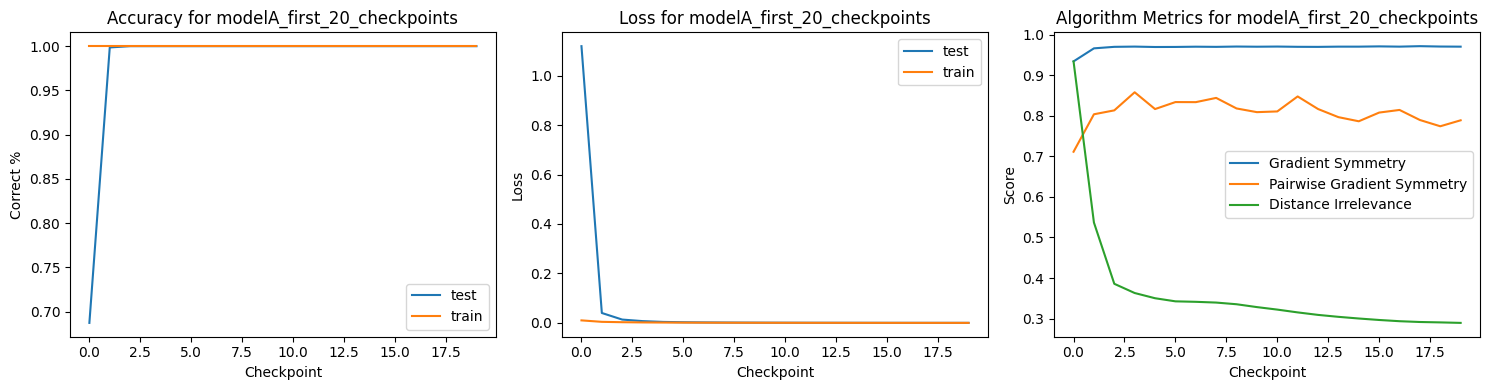

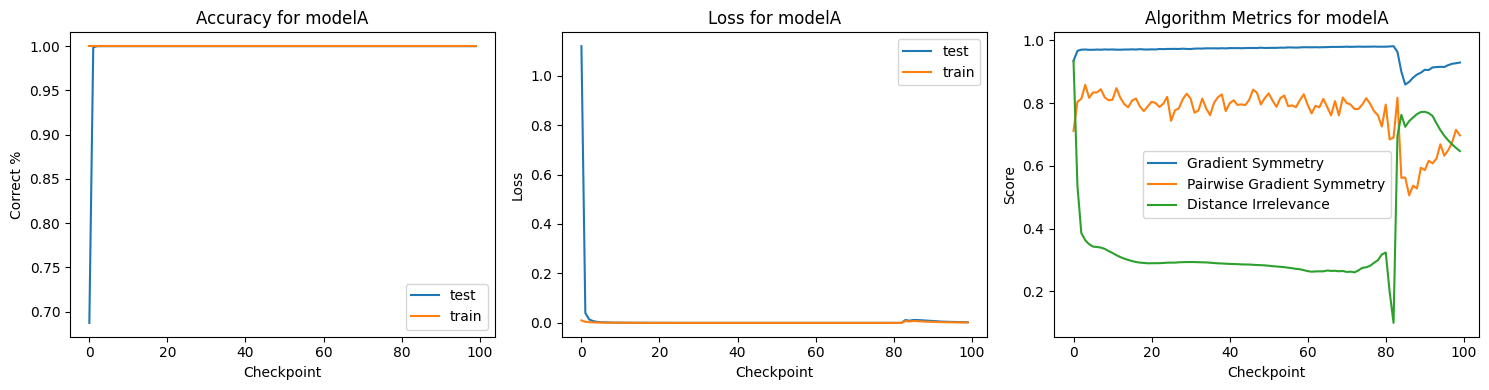

In [ ]:
torch.manual_seed(model_a_params.random_seed)

dataset = make_dataset(model_a_params.p)
train_data, test_data = train_test_split(dataset, model_a_params.train_frac, model_a_params.random_seed)

all_checkpointed_models_a, df_a = train(
    train_dataset=train_data, test_dataset=test_data, all_data=dataset, params=model_a_params, model_type='transformer'
)

save_plots(all_checkpointed_models_a[:20], df_a[:20], "modelA_first_20_checkpoints")

save_plots(all_checkpointed_models_a, df_a, "modelA")

We get some interesting results! For the first ~20,000 iterations of training, as expected, our algorithm metrics suggest an algorithm that treats its inputs symmetrically. We have very high gradient symmetry (as defined by the original Pizza/Clock paper).

We would expect a purely symmetric pizza algorithm to have near 1.0 pairwise gradient symmetry, but we do see it hover around 0.8. Relatively high, but it means rearranging the inputs has *some* effect on the output logits. This may be the work of the learnable positional encoding layer, and learning an asymmetric algorithm is in theory possible.

Perhaps most interesting of all, after enough iterations, we see a sudden, sharp change in these metrics, accompanied by a small spike in loss.

Let's get an LLC estimation, to see if there's any correlation there.

/usr/local/lib/python3.12/dist-packages/devinterp/slt/sampler.py:117: UserWarning: Using passed in nbeta. Make sure callbacks are also initialized with the same nbeta.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/devinterp/backends/default/slt/sampler.py:240: UserWarning: You are taking more draws than burn-in steps, your LLC estimates will likely be underestimates. Please check LLC chain convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/devinterp/backends/default/slt/sampler.py:244: UserWarning: You are taking more sample batches than there are dataloader batches available, this removes some randomness from sampling but is probably fine. (All sample batches beyond the number dataloader batches are cycled from the start, f.e. 9 samples from [A, B, C] would be [B, A, C, B, A, C, B, A, C].)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/devinterp/backends/default/slt/sampler.py:285: UserWarning: If you're setting a nbeta or temperature in optimiz

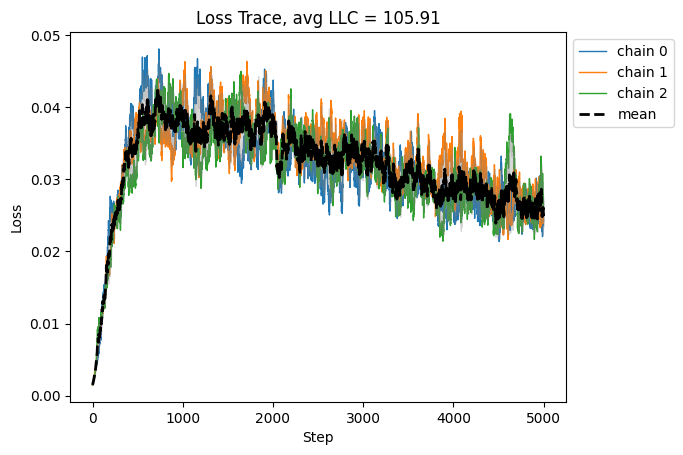

<Figure size 1200x900 with 0 Axes>

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/devinterp/slt/llc.py:109: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.llc_std = self.llc_per_chain.std()


In [ ]:
model_a_llc_params = LlcEstimationParams(batch_size=model_a_params.batch_size, nbeta=len(dataset))

compute_and_plot_llc_loss_trace(all_checkpointed_models_a, df_a, "modelA", model_a_llc_params)

model_a_llcs = compute_llc(all_checkpointed_models_a, df_a, "modelA", model_a_llc_params)

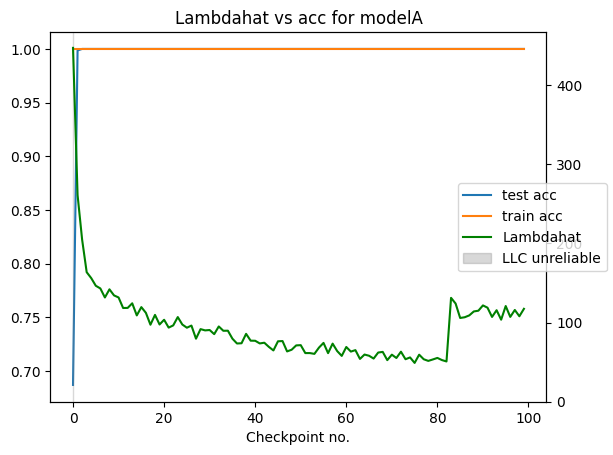

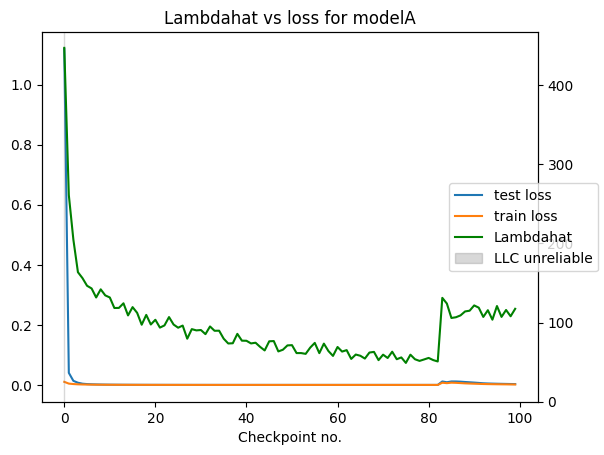

In [ ]:
plot_llcs(all_checkpointed_models_a, df_a, "modelA", model_a_llcs)

In [ ]:
print("Final checkpoint LLC estimate:", model_a_llcs[-1]["llc/mean"])
min_llc, min_idx = min((v, i) for (i, v) in enumerate([llc["llc/mean"] for llc in model_a_llcs if llc["llc/mean"] > 0]))
print("Minimum nonzero LLC estimate:", min_llc, "at checkpoint", min_idx)

Final checkpoint LLC estimate: 117.42341613769531
Minimum nonzero LLC estimate: 49.05731201171875 at checkpoint 75


The LLC tracks the other metrics! The most prominent observations here are that:

1. The model groks *very* early on. This is accompanied by sharp drops in the LLC, as expected.
2. Around checkpoint 80, when we see that loss bump, and rapid algo metric change, we also observe the LLC sharply increase.

#### Regular Attention (Model B)

Training: 100%|██████████| 25000/25000 [12:36<00:00, 33.07it/s, train_loss=0.002184, train_acc=1.000000, val_loss=0.003329, val_acc=1.000000, model_sg=-0.238782, model_di=0.942115, model_sp=0.878465]


Final Train Acc: 1.000000 | Final Train Loss: 0.002184
Final Val Acc: 1.000000 | Final Val Loss: 0.003329
Final SG: -0.226871 | Final DI: 0.942115 | Final SP: 0.873678


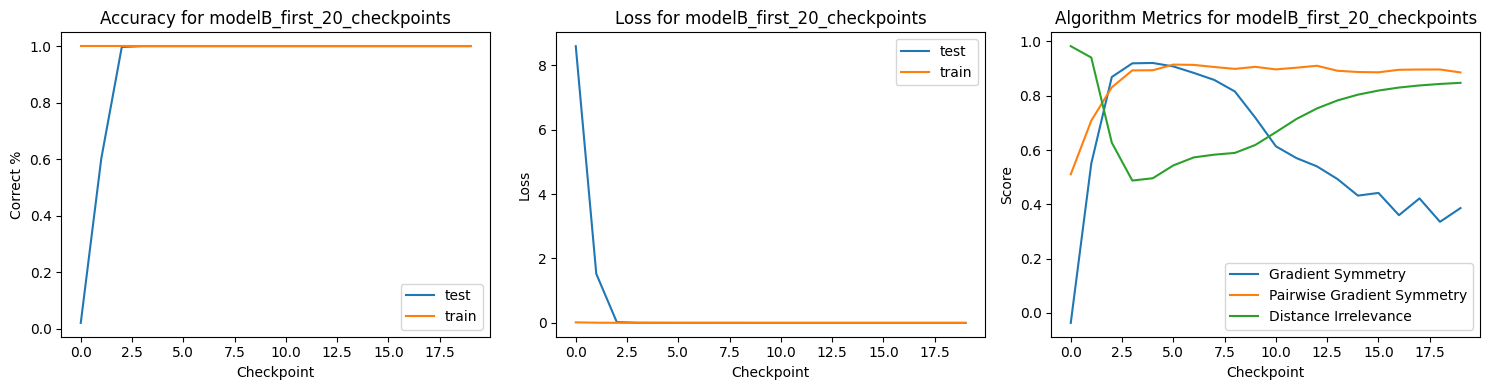

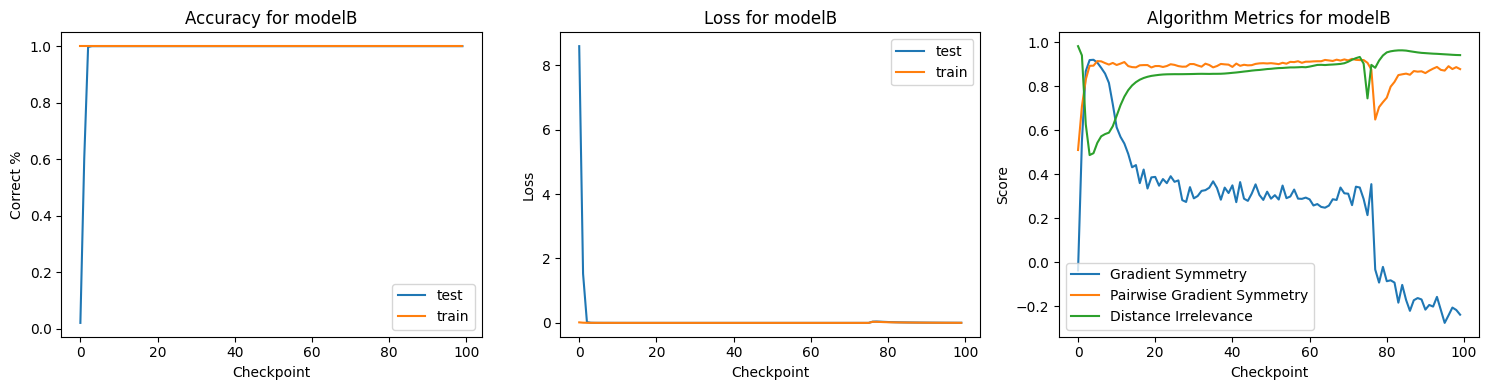

In [ ]:
torch.manual_seed(model_b_params.random_seed)

dataset = make_dataset(model_b_params.p)
train_data, test_data = train_test_split(dataset, model_b_params.train_frac, model_b_params.random_seed)

all_checkpointed_models_b, df_b = train(
    train_dataset=train_data, test_dataset=test_data, all_data=dataset, params=model_b_params, model_type='transformer'
)

save_plots(all_checkpointed_models_b[:20], df_b[:20], "modelB_first_20_checkpoints")

save_plots(all_checkpointed_models_b, df_b, "modelB")

Yet another interesting finding!

At first, we seem to reproduce the findings of Pizza/Clock. Their ModelB achieved a grad symmetry of .3336, a distance irrelevance of .85, which is very close to our ModelB. However, they only provided this final score, but looking at how we got there:

1. Gradient symmetry sharply rises as it groks.
2. After that, gradient symmetry trends down, until a sudden phase change around checkpoint 80.
3. Pairwise gradient symmetry is always high, which is strange. A "clock" algorithm would imply argument order matters. **However,** this may just be due to a flaw in this metric.

Our train and test accuracy are already fully saturated in less than 1000 iterations, yet somehow, despite performing the task perfectly, we can optimize further. And if we *keep* optimizing, we get a loss bump, and *some* phase change seems to occur which changes our algo metrics dramatically.

Again, let's get an LLC estimation

Chain 2: 100%|██████████| 5000/5000 [01:29<00:00, 55.93it/s]


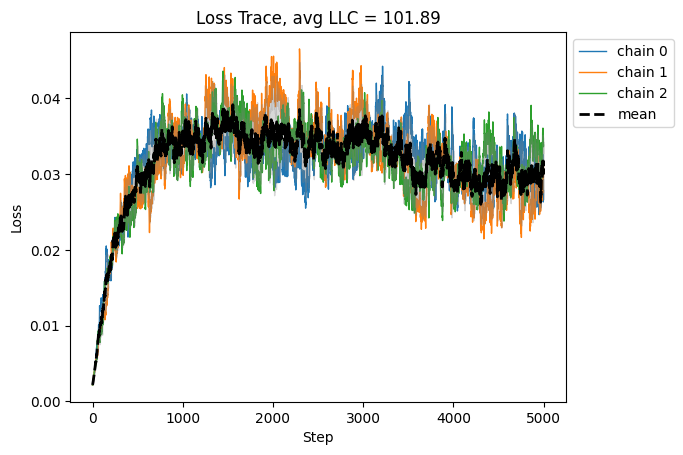

<Figure size 1200x900 with 0 Axes>

<Figure size 640x480 with 0 Axes>

In [ ]:
model_b_llc_params = LlcEstimationParams(batch_size=model_b_params.batch_size, nbeta=len(dataset))

compute_and_plot_llc_loss_trace(all_checkpointed_models_b, df_b, "modelB", model_b_llc_params)

model_b_llcs = compute_llc(all_checkpointed_models_b, df_b, "modelB", model_b_llc_params)

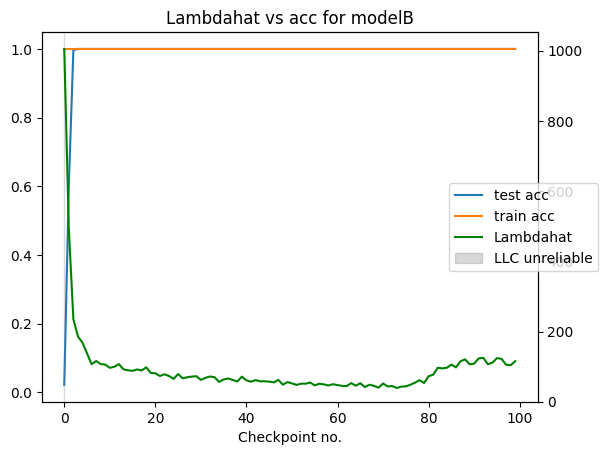

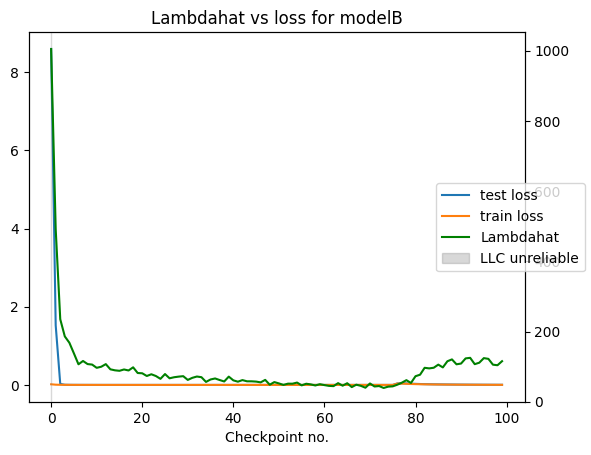

In [ ]:
plot_llcs(all_checkpointed_models_b, df_b, "modelB", model_b_llcs)

In [ ]:
print("Final checkpoint LLC estimate:", model_b_llcs[-1]["llc/mean"])
min_llc, min_idx = min((v, i) for (i, v) in enumerate([llc["llc/mean"] for llc in model_b_llcs if llc["llc/mean"] > 0]))
print("Minimum nonzero LLC estimate:", min_llc, "at checkpoint", min_idx)

Final checkpoint LLC estimate: 115.46863555908203
Minimum nonzero LLC estimate: 39.18190002441406 at checkpoint 73


We've successfully reproduced the 2 basic models, and our findings appear to track.

ModelA learns an algorithm with symmetric gradients, and logit predictions sensitive to distance. While ModelB learns an algorithm with asymmetric gradients.

Furthermore, both models seem to keep learning as they minimize loss, despite getting full accuracy on both train and test.

SLT claims this learning aims to reduce the "dimensionality" of the learned algorithm, supported by the decreasing LLC as training continues.

### MLP Runs

**NOTE:**  The MLP run is more of a tangent and the MLP hyperparameters were matched to the transformer for comparability, which means it was trained with absurd hyperparams. Despite this (and possibly poor SGLD hyperparams), the LLC remained resilient.

A much more sensible MLP training run could be found in [the grokking notebook](https://github.com/timaeus-research/devinterp/blob/main/examples/grokking.ipynb), which succeeded in learning modular arithmetic with an LLC of around 23-27.

Training: 100%|██████████| 25000/25000 [06:18<00:00, 66.07it/s, train_loss=0.000001, train_acc=1.000000, val_loss=0.000002, val_acc=1.000000, model_sg=0.083594, model_di=0.934653, model_sp=0.844423]


Final Train Acc: 1.000000 | Final Train Loss: 0.000001
Final Val Acc: 1.000000 | Final Val Loss: 0.000002
Final SG: 0.020916 | Final DI: 0.934653 | Final SP: 0.846627


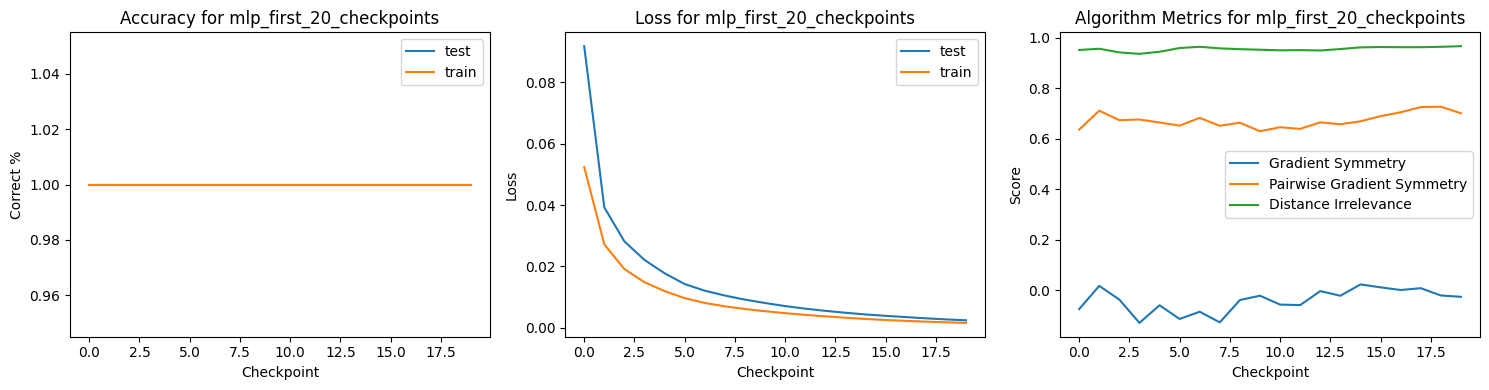

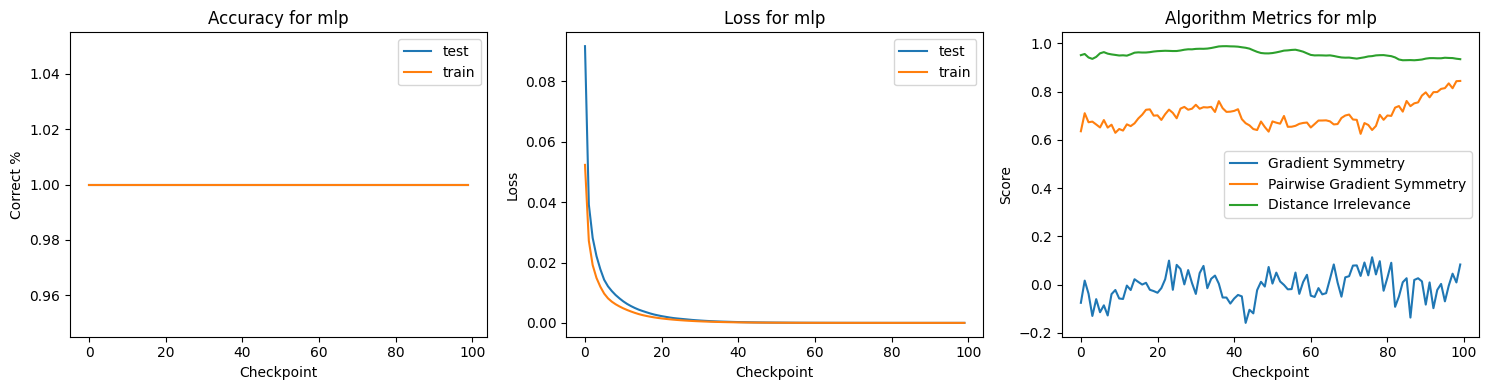

In [ ]:
mlp_params = MlpExperimentParams(
    p = 59,
    n_batches = 25000, # This is a *lot* but we want to see how LLC evolves.
    n_save_model_checkpoints = 100,
    print_times = 100,
    lr = .01, # Higher LR for MLP
    train_frac = 0.8,
    batch_size = int(59 * 59 * .8),
    random_seed = 42, # Original code didn't provide a fixed seed, but used `42` for sampling during gradient symmetry computation
    device = DEVICE,
    weight_decay = .5, # Lower wd for MLP
    hidden_size = 48,
    embed_dim = 12,
)
torch.manual_seed(mlp_params.random_seed)

dataset = make_dataset(mlp_params.p)
train_data, test_data = train_test_split(dataset, mlp_params.train_frac, mlp_params.random_seed)

all_checkpointed_models_mlp, df_mlp = train(
    train_dataset=train_data, test_dataset=test_data, all_data=dataset, params=mlp_params, model_type='mlp'
)

save_plots(all_checkpointed_models_mlp[:20], df_mlp[:20], "mlp_first_20_checkpoints")

save_plots(all_checkpointed_models_mlp, df_mlp, "mlp")

Well, our training for the MLP appears to be complete overkill. It generalized pretty much immediately, and spent the rest of the time seemingly spinning in circles. Considering we trained it for quite a lot of time, with the same training hyperparams as much more complicated transformer models, I should have seen this coming.

Interpreting our algorithm metrics, a high distance irrelevance and low gradient symmetricity would imply the MLP learned a clock-like algorithm. Considering the MLP is position dependent, and `x[0]` and `x[1]` go through separate linear layers, it does have the capability to do so.  

Although this model might not really be that insightful to look at, let's look at the LLC anyways:

/usr/local/lib/python3.12/dist-packages/devinterp/slt/sampler.py:117: UserWarning: Using passed in nbeta. Make sure callbacks are also initialized with the same nbeta.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/devinterp/backends/default/slt/sampler.py:240: UserWarning: You are taking more draws than burn-in steps, your LLC estimates will likely be underestimates. Please check LLC chain convergence.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/devinterp/backends/default/slt/sampler.py:244: UserWarning: You are taking more sample batches than there are dataloader batches available, this removes some randomness from sampling but is probably fine. (All sample batches beyond the number dataloader batches are cycled from the start, f.e. 9 samples from [A, B, C] would be [B, A, C, B, A, C, B, A, C].)
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/devinterp/backends/default/slt/sampler.py:285: UserWarning: If you're setting a nbeta or temperature in optimiz

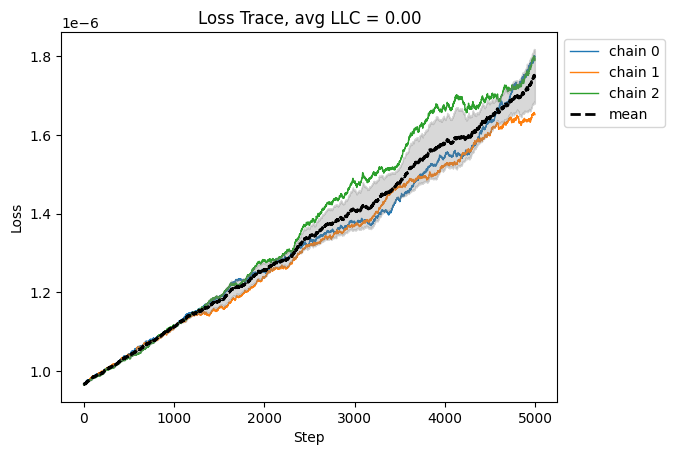

<Figure size 1200x900 with 0 Axes>

<Figure size 640x480 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/devinterp/slt/llc.py:109: UserWarning: std(): degrees of freedom is <= 0. Correction should be strictly less than the reduction factor (input numel divided by output numel). (Triggered internally at /pytorch/aten/src/ATen/native/ReduceOps.cpp:1857.)
  self.llc_std = self.llc_per_chain.std()


In [ ]:
model_mlp_llc_params = LlcEstimationParams(
    lr=1e-7,
    gamma=500,
    batch_size=mlp_params.batch_size,
    nbeta=len(dataset),
    num_draws = 2000,
    num_burnin_steps = 500,
  )

compute_and_plot_llc_loss_trace(all_checkpointed_models_mlp, df_mlp, "modelMLP", model_mlp_llc_params)

model_mlp_llcs = compute_llc(all_checkpointed_models_mlp, df_mlp, "modelMLP", model_mlp_llc_params)

**That loss trace looks quite bad! And it's estimating the average LLC to be near 0!** But this could just be due to us overtraining the model very hard, to the point where the LLC is near 0. I think that one or both of the following had happened:

1. The hyperparameter selection for SGLD was poor, and **the LLC estimates I've taken are basically unusable** as a result. Or,
2. I've overtrained the model for so long, that the LLC is near 0.

I'm keeping this here, just because it's sort of fun to see what happens to as we overcook a model. I don't think its inclusion detracts from the transformer vs const attn results, and those are much more well behaved.

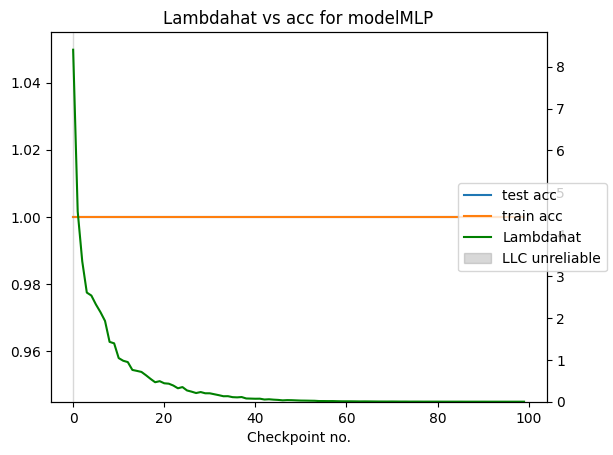

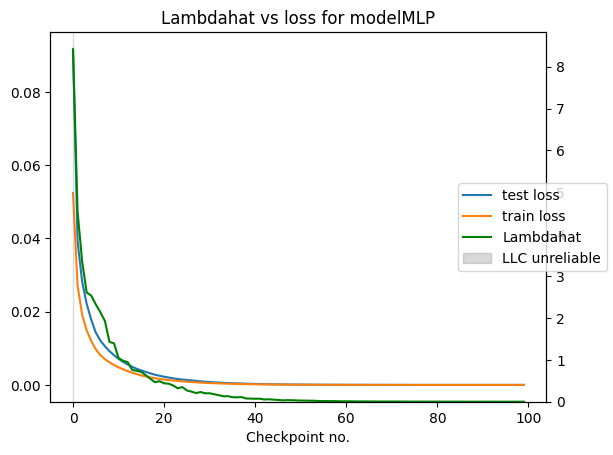

In [ ]:
plot_llcs(all_checkpointed_models_mlp, df_mlp, "modelMLP", model_mlp_llcs)

In [ ]:
print("Final checkpoint LLC estimate:", model_mlp_llcs[-1]["llc/mean"])
min_llc, min_idx = min((v, i) for (i, v) in enumerate([llc["llc/mean"] for llc in model_mlp_llcs if llc["llc/mean"] > 0]))
print("Minimum nonzero LLC estimate:", min_llc, "at checkpoint", min_idx)

Final checkpoint LLC estimate: 0.000740265822969377
Minimum nonzero LLC estimate: 0.000740265822969377 at checkpoint 99


Again, **I wouldn't put any stock at all into this result for the MLP**. I've chosen to keep it in,
I don't think the method is flawed, just the hyperparameter selection needs some care.

### (Incomplete) Ablations

A couple of ablations could be found in `Modular_Arithmetic_Grokking_Ablations.ipynb`.

Although many ablations were included, the ones that were actually run and working are:

```
    # --- Disable Positional Encoding ---
    make_ablation(TRANSFORMER_BASELINE, pos_embed_type='none'),
    make_ablation(CONST_ATTN_BASELINE, pos_embed_type='none'),

    # --- Width ablations for transformer ---
    make_ablation(TRANSFORMER_BASELINE, d_model=32),
    make_ablation(TRANSFORMER_BASELINE, d_model=256),

    # --- Width ablations for const attention ---
    make_ablation(CONST_ATTN_BASELINE, d_model=32),
```

From these it is suggested that LLC for transformer models decreased with reduced model dimensionality, and that even with positional encoding disabled the transformer model learned an algorithm with lower gradient symmetry.

## Closing Thoughts

This was my first DevInterp project, and I wasn't sure what to expect or look for going in. I came in with the sole idea of idea "reproduce the Pizza/Clock paper's models, then compare LLC values on the reproduction," and just kinda did whatever felt like followed next at each step.

Regardless, I *did* get a reproduction working and was able to make a couple of observations:

- In all 3 model types, the LLC correlates with loss.
- In the Transformer and Const Attn models, the LLC correlated with changes in algorithm metrics.
- In the Transformer and Const Attn models, the LLC reached minimums of approximately 39 and 49 at checkpoints 73 and 75 respectively for this run; Additional seeds should be tested for more confidence in results.
- When trained long enough, the Transformer and Const Attn models appear to undergo a second phase change, post-grokking, where the LLC rises. Both models final LLCs were similar at approximately 115 and 117.
- MLP was likely overtrained, and hyperparameter selection for SGLD could be improved. My LLC estimate on the MLP model is near 0, which is a strange result. (The [reference](https://github.com/timaeus-research/devinterp/blob/main/examples/grokking.ipynb) finds it is closer to 23,under more grounded training conditions).

There's a *lot* more I could have done. But as a first project, I ultimately decided to just get in, take some LLC estimates, and get out.

I'm not sure if I'm going to continue iterating on this specific problem, but there's a lot of room for improvement, not limited to:

1. Code quality is poor. If I want to revisit this I'll have to clean up.
2. Fix the ablations.
3. I'm still wrapping my head around theory, so I can't provide much theoretical insight into observations. DevInterp and SLT seem quite mathematically daunting to get into. As fun as making line go down and smashing half-broken code together was, I was absolutely wandering in the dark.
4. The MLP model could have been reproduced better. I trained it with similar hyperparams to the transformer models, which probably was not the best control.

Possible follow ups for something more real include:

- How does the second phase change behave? Longer training to see that to completion?
- Performing the full breadth of analysis that Pizza/Clock did to discern algorithms (PCAs, attention patterns, circuit tracing).
- Better MLP training
- A closer look at why pairwise gradient symmetry failed to capture the same info as sampled gradient symmetricity
- Analyzing the model after the second phase change, to see if the algorithm changes there

This essentially was an "extended tutorial" mini-project, where I reproduced some models from a paper, then combined it with a different notebook. Certainly not research quality, but it was fun, was a good warmup and I convinced myself that the LLC does something, which is what I think I wanted to get out of it?